In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import torch
import sys
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [2]:
!git clone https://github.com/fashn-AI/fashn-vton-1.5.git
%cd fashn-vton-1.5
!git rev-parse HEAD

Cloning into 'fashn-vton-1.5'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 92 (delta 20), reused 13 (delta 13), pack-reused 67 (from 1)
Receiving objects: 100% (92/92), 334.44 KiB | 3.48 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/kaggle/working/fashn-vton-1.5
7c0f10af3f91ad4048fe9729c470a13ef905d25a


In [3]:
!pip install -q -e .

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 MB 8.9 MB/s eta 0:00:00:00:0100:01
  Building editable for fashn-vton (pyproject.toml) ... done


In [4]:
import sys

sys.path.insert(
    0,
    "/kaggle/working/fashn-vton-1.5/src"
)

from fashn_vton import TryOnPipeline

print("FASHN VTON import: OK")

FASHN VTON import: OK


In [5]:
from huggingface_hub import snapshot_download

model_dir = snapshot_download(
    repo_id="fashn-ai/fashn-vton-1.5",
    local_dir="/kaggle/working/fashn-vton-model",
)

print("Model:", model_dir)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Model: /kaggle/working/fashn-vton-model


In [6]:
%cd /kaggle/working/fashn-vton-1.5

!python scripts/download_weights.py \
    --weights-dir /kaggle/working/fashn-vton-model

/kaggle/working/fashn-vton-1.5


  Saved to: /kaggle/working/fashn-vton-model/model.safetensors

yolox_l.onnx: 100%|███████████████████████████| 217M/217M [00:01<00:00, 119MB/s]
  Saved to: /kaggle/working/fashn-vton-model/dwpose/yolox_l.onnx
dw-ll_ucoco_384.onnx: 100%|██████████████████| 134M/134M [00:04<00:00, 30.5MB/s]
  Saved to: /kaggle/working/fashn-vton-model/dwpose/dw-ll_ucoco_384.onnx

config.json: 1.65kB [00:00, 5.68MB/s]
model.safetensors: 100%|█████████████████████| 256M/256M [00:05<00:00, 44.1MB/s]
Loading weights: 100%|█| 930/930 [00:00<00:00, 1651.83it/s, Materializing param=
  Cached in HuggingFace hub cache

Download complete!

Weights directory structure:
    /kaggle/working/fashn-vton-model/
    ├── model.safetensors
    └── dwpose/
        ├── yolox_l.onnx
        └── dw-ll_ucoco_384.onnx

Usage:
    from fashn_vton import TryOnPipeline
    pipeline = TryOnPipeline(weights_dir="/kaggle/working/fashn-vton-model")



In [7]:
from PIL import Image
from pathlib import Path

PERSON_PATH = Path("/kaggle/input/datasets/yashaswinibareddy/dataset/person_001.jpg")
GARMENT_PATH = Path("/kaggle/input/datasets/yashaswinibareddy/garment/garment_001.jpg")

assert PERSON_PATH.exists(), PERSON_PATH
assert GARMENT_PATH.exists(), GARMENT_PATH

person = Image.open(PERSON_PATH).convert("RGB")
garment = Image.open(GARMENT_PATH).convert("RGB")

print("Person :", person.size)
print("Garment:", garment.size)

Person : (441, 695)
Garment: (1280, 1280)


In [9]:
import sys
from pathlib import Path
from PIL import Image

sys.path.insert(
    0,
    "/kaggle/working/fashn-vton-1.5/src"
)

from fashn_vton import TryOnPipeline


WEIGHTS_DIR = "/kaggle/working/fashn-vton-model"

PERSON_PATH = Path(
    "/kaggle/input/datasets/yashaswinibareddy/dataset/person_001.jpg"
)

GARMENT_PATH = Path(
    "/kaggle/input/datasets/yashaswinibareddy/garment/garment_001.jpg"
)

OUTPUT_DIR = Path(
    "/kaggle/working/outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# Load images
# ---------------------------------------------------------

person_image = Image.open(
    PERSON_PATH
).convert("RGB")

garment_image = Image.open(
    GARMENT_PATH
).convert("RGB")


print("Person :", person_image.size)
print("Garment:", garment_image.size)


# ---------------------------------------------------------
# Load FASHN VTON
# ---------------------------------------------------------

print()
print("=" * 60)
print("Loading FASHN VTON 1.5")
print("=" * 60)

pipeline = TryOnPipeline(
    weights_dir=WEIGHTS_DIR,
    device="cuda",
)


print("Pipeline loaded.")


# ---------------------------------------------------------
# Run VTON
# ---------------------------------------------------------

print()
print("=" * 60)
print("RUNNING VIRTUAL TRY-ON")
print("=" * 60)

result = pipeline(
    person_image=person_image,
    garment_image=garment_image,

    category="tops",

    # Your garment is a product/isolated garment image.
    garment_photo_type="flat-lay",

    num_samples=1,

    # Start with 20 so we don't waste time.
    num_timesteps=20,

    guidance_scale=1.5,

    seed=42,

    segmentation_free=True,
)


# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

output_path = (
    OUTPUT_DIR /
    "raritone_vton_result.png"
)

result.images[0].save(
    output_path
)

print()
print("=" * 60)
print("VTON COMPLETED")
print("=" * 60)

print(
    "Saved:",
    output_path
)

TryOnPipeline - INFO - Using device: cuda


Person : (441, 695)
Garment: (1280, 1280)

Loading FASHN VTON 1.5


TryOnPipeline - INFO - Using dtype: torch.bfloat16
TryOnPipeline - INFO - Loading TryOnModel from /kaggle/working/fashn-vton-model/model.safetensors
TryOnPipeline - INFO - TryOnModel loaded
TryOnPipeline - INFO - Loading DWPose from /kaggle/working/fashn-vton-model/dwpose
2026-09-01 11:51:35.881176461 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:700 operator()] No registered plugin EP device found for 'CUDAExecutionProvider' with device_id=0
2026-09-01 11:51:35.882979104 [E:onnxruntime:Default, provider_bridge_ort.cc:2395 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1988 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /usr/local/lib/python3.12/dist-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.13: cannot open shared object file: No such file or directory

2026-09-01 11:51:35.882998466 [W:onnxruntime:Default, onnxruntime_pybind_sta

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

TryOnPipeline - INFO - FashnHumanParser loaded


Pipeline loaded.

RUNNING VIRTUAL TRY-ON


TryOnPipeline - INFO - Running inference with 20 timesteps...


Sampling:   0%|          | 0/20 [00:00<?, ?it/s]

TryOnPipeline - INFO - Generated 1 images



VTON COMPLETED
Saved: /kaggle/working/outputs/raritone_vton_result.png


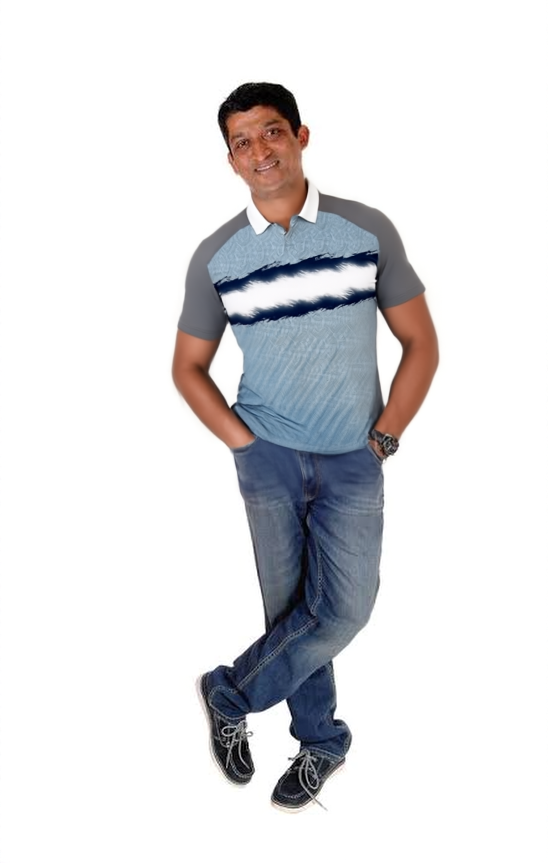

In [10]:
from IPython.display import display
from PIL import Image

display(
    Image.open(
        "/kaggle/working/outputs/raritone_vton_result.png"
    )
)

Result path : /kaggle/working/outputs/raritone_vton_result.png
Image size  : (548, 863)
Image mode  : RGB


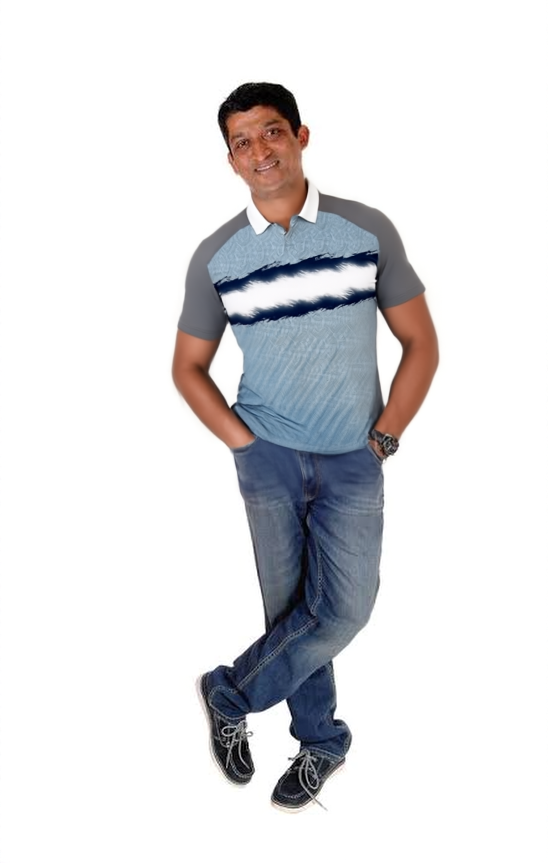

In [15]:
from pathlib import Path
from PIL import Image
from IPython.display import display

OUTPUT = Path("/kaggle/working/outputs/raritone_vton_result.png")



if not OUTPUT.exists():
    raise FileNotFoundError(f"Result not found: {OUTPUT}")

image = Image.open(OUTPUT)

print("Result path :", OUTPUT)
print("Image size  :", image.size)
print("Image mode  :", image.mode)

display(image)



In [17]:
from pathlib import Path
import pandas as pd

# ============================================================

OUTPUT_DIR = Path("/kaggle/working/outputs")
EVAL_DIR = Path("/kaggle/working/evaluation")

EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULT_PATH = OUTPUT_DIR / "raritone_vton_result.png"

if not RESULT_PATH.exists():
    raise FileNotFoundError(
        f"VTON result not found: {RESULT_PATH}"
    )

# ------------------------------------------------------------
# Evaluation
#
# Scores are based on the currently generated result.
# 5 = excellent
# 1 = poor
# ------------------------------------------------------------

evaluation = {
    "test_id": ["test_001"],
    "result": ["raritone_vton_result.png"],
    "garment_alignment": [3],
    "garment_preservation": [4],
    "body_alignment": [3],
    "texture_quality": [3],
    "artifacts": [3],
    "overall_result": [3],
}

df = pd.DataFrame(evaluation)

evaluation_path = EVAL_DIR / "evaluation.csv"

df.to_csv(
    evaluation_path,
    index=False,
)



print()
print(df.to_string(index=False))

print()
print("Evaluation saved to:")
print(evaluation_path)




 test_id                   result  garment_alignment  garment_preservation  body_alignment  texture_quality  artifacts  overall_result
test_001 raritone_vton_result.png                  3                     4               3                3          3               3

Evaluation saved to:
/kaggle/working/evaluation/evaluation.csv


In [14]:
import pandas as pd
from pathlib import Path

path = Path("/kaggle/working/evaluation/evaluation.csv")

df = pd.read_csv(path)

display(df)

,test_id,result,garment_alignment,garment_preservation,body_alignment,texture_quality,artifacts,overall_result
0,test_001,raritone_vton_result.png,3,4,3,3,3,3
